# Model Selection and Final Evaluation

Tujuan:

Notebook ini bertujuan mengevaluasi dan membandingkan seluruh model yang telah dikembangkan pada tahap sebelumnya untuk menentukan model yang paling sesuai digunakan sebagai production model.

Evaluasi dilakukan berdasarkan hasil eksperimen:

- Baseline Modeling
- Historical Modeling
- Elo Modeling
- Advanced Modeling

Notebook ini tidak melakukan pelatihan model baru. Seluruh evaluasi menggunakan metrics dan model yang telah dihasilkan pada notebook sebelumnya.

## 1. Import
Tujuan: Library yang digunakan pada tahap ini berfokus pada pengolahan, visualisasi, dan evaluasi hasil eksperimen yang telah tersimpan.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Project paths
REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")

## 2. Load Model Metrics 
Hasil evaluasi dari seluruh tahap modeling sebelumnya disimpan dalam file CSV terpisah. Pada tahap ini seluruh metrics tersebut akan dimuat untuk membentuk satu benchmark hasil eksperimen.

In [4]:
baseline_metrics = pd.read_csv(
    REPORTS_DIR / "baseline_metrics.csv"
)

historical_metrics = pd.read_csv(
    REPORTS_DIR / "historical_metrics.csv"
)

elo_metrics = pd.read_csv(
    REPORTS_DIR / "elo_metrics.csv"
)

advanced_metrics = pd.read_csv(
    REPORTS_DIR / "advanced_metrics.csv"
)

display(baseline_metrics)
display(historical_metrics)
display(elo_metrics)
display(advanced_metrics)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.572975,0.521363,0.572975,0.509571
1,Random Forest,0.508445,0.470924,0.508445,0.478398


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.580459,0.526805,0.580459,0.520899
1,Random Forest,0.546677,0.495492,0.546677,0.471682


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.593203,0.558947,0.593203,0.512776
1,Random Forest,0.576919,0.527102,0.576919,0.509791


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.591888,0.537479,0.591888,0.521782
1,LightGBM,0.591686,0.536832,0.591686,0.523613


## 3. Combine Model Metrics
Hasil evaluasi dari setiap tahap modeling akan digabungkan menjadi satu tabel benchmark. Informasi mengenai tahap eksperimen (*stage*) ditambahkan agar setiap model dapat diidentifikasi berdasarkan feature set dan algoritma yang digunakan.

### 3.1 Combine

In [5]:
# Add experiment stage
baseline_metrics["Stage"] = "Baseline"
historical_metrics["Stage"] = "Historical"
elo_metrics["Stage"] = "Elo"
advanced_metrics["Stage"] = "Advanced"

In [6]:
all_metrics = pd.concat(
    [
        baseline_metrics,
        historical_metrics,
        elo_metrics,
        advanced_metrics
    ],
    ignore_index=True
)

all_metrics = all_metrics[
    [
        "Stage",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]


display(all_metrics)

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,Logistic Regression,0.572975,0.521363,0.572975,0.509571
1,Baseline,Random Forest,0.508445,0.470924,0.508445,0.478398
2,Historical,Logistic Regression,0.580459,0.526805,0.580459,0.520899
3,Historical,Random Forest,0.546677,0.495492,0.546677,0.471682
4,Elo,Logistic Regression,0.593203,0.558947,0.593203,0.512776
5,Elo,Random Forest,0.576919,0.527102,0.576919,0.509791
6,Advanced,XGBoost,0.591888,0.537479,0.591888,0.521782
7,Advanced,LightGBM,0.591686,0.536832,0.591686,0.523613


### 3.2 Leaderboard

In [7]:
leaderboard = all_metrics.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(leaderboard)

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,Elo,Logistic Regression,0.593203,0.558947,0.593203,0.512776
1,Advanced,XGBoost,0.591888,0.537479,0.591888,0.521782
2,Advanced,LightGBM,0.591686,0.536832,0.591686,0.523613
3,Historical,Logistic Regression,0.580459,0.526805,0.580459,0.520899
4,Elo,Random Forest,0.576919,0.527102,0.576919,0.509791
5,Baseline,Logistic Regression,0.572975,0.521363,0.572975,0.509571
6,Historical,Random Forest,0.546677,0.495492,0.546677,0.471682
7,Baseline,Random Forest,0.508445,0.470924,0.508445,0.478398


### 3.3 Accuracy Comparison

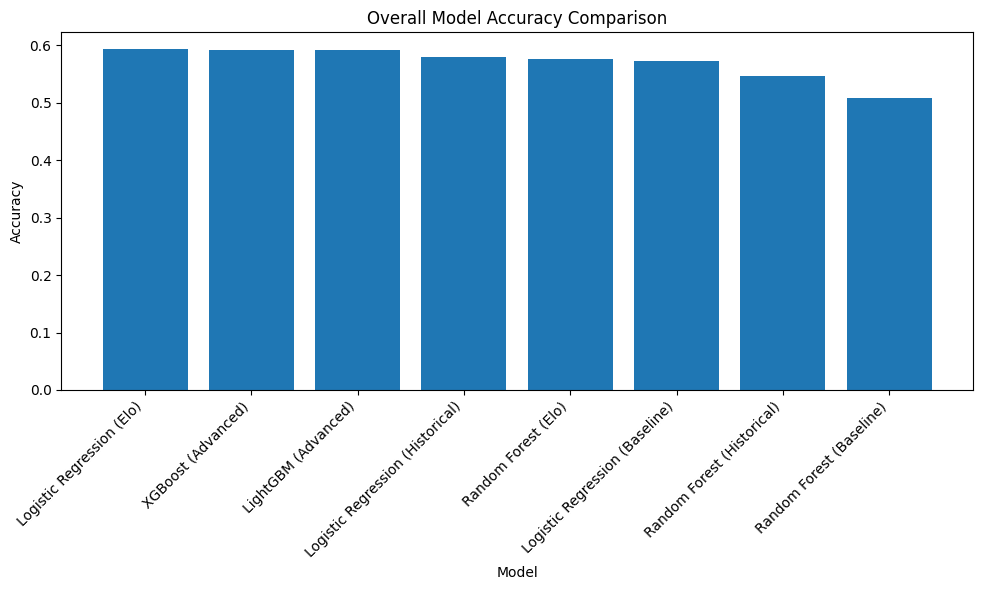

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    leaderboard["Model"] + " (" + leaderboard["Stage"] + ")",
    leaderboard["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Overall Model Accuracy Comparison")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Dalam perbandingan Accuracy, Logistic Regression menjadi yang terbaik dengan nilai 0.59 diikuti oleh XGBoost dan LightGBM.

### 3.4 F1 Comparison

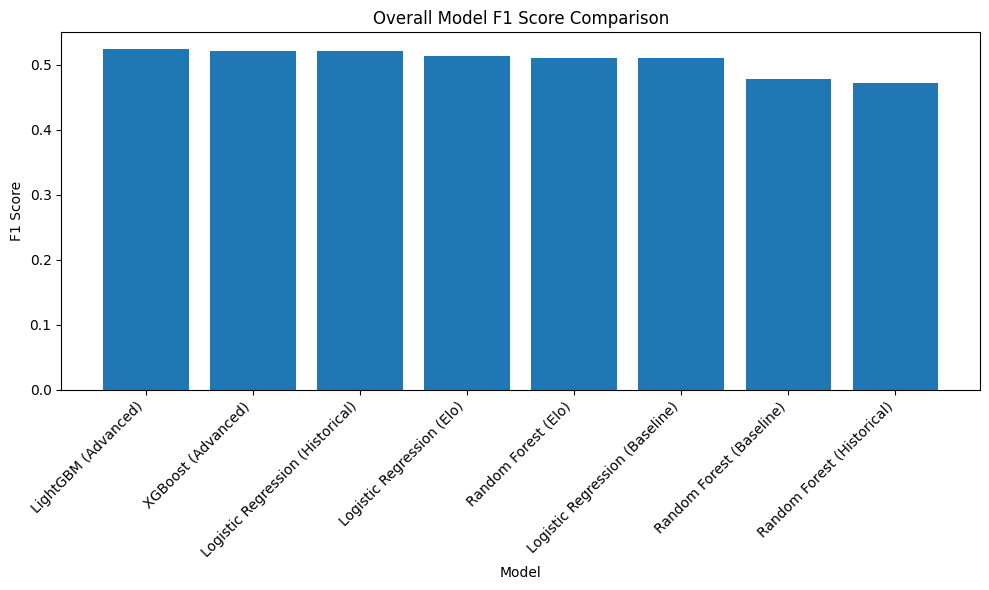

In [9]:
f1_ranking = all_metrics.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.bar(
    f1_ranking["Model"] + " (" + f1_ranking["Stage"] + ")",
    f1_ranking["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Overall Model F1 Score Comparison")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Dalam perbandingan F1 Score, LightGBM menjadi yang terbaik dengan nilai 0.59 diikuti oleh XGBoost dan Logistic Regression.

### 3.5 Feature Progression

In [10]:
lr_progression = all_metrics[
    all_metrics["Model"] == "Logistic Regression"
].copy()

stage_order = {
    "Baseline": 0,
    "Historical": 1,
    "Elo": 2
}

lr_progression["Order"] = lr_progression["Stage"].map(
    stage_order
)

lr_progression = lr_progression.sort_values("Order")

lr_progression[
    ["Stage", "Accuracy", "F1 Score"]
]

,Stage,Accuracy,F1 Score
0,Baseline,0.572975,0.509571
2,Historical,0.580459,0.520899
4,Elo,0.593203,0.512776


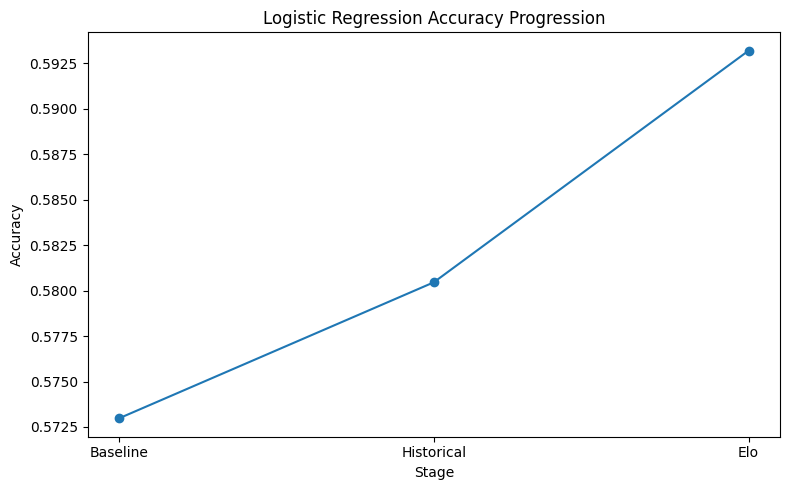

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_progression["Stage"],
    lr_progression["Accuracy"],
    marker="o"
)

plt.ylabel("Accuracy")
plt.xlabel("Stage")
plt.title("Logistic Regression Accuracy Progression")

plt.tight_layout()
plt.show()

Grafik tersebut menunjukan bahwa performa Accuracy dari Logistic Regression meningkat seiring stage/experiment berlanjut. Hal ini kemungkinan besar disebabkan oleh kualitas detail data yang meningkat.

In [12]:
baseline_acc = lr_progression.loc[
    lr_progression["Stage"] == "Baseline",
    "Accuracy"
].iloc[0]

historical_acc = lr_progression.loc[
    lr_progression["Stage"] == "Historical",
    "Accuracy"
].iloc[0]

elo_acc = lr_progression.loc[
    lr_progression["Stage"] == "Elo",
    "Accuracy"
].iloc[0]

In [13]:
historical_improvement = historical_acc - baseline_acc
elo_improvement = elo_acc - historical_acc
total_improvement = elo_acc - baseline_acc

print(f"Baseline → Historical: +{historical_improvement:.4f}")
print(f"Historical → Elo:      +{elo_improvement:.4f}")
print(f"Baseline → Elo:        +{total_improvement:.4f}")

Baseline → Historical: +0.0075
Historical → Elo:      +0.0127
Baseline → Elo:        +0.0202


## 4. Final Model Selection

Tahap ini bertujuan menentukan model utama yang akan digunakan pada tahap deployment dan Prediction API.

Pemilihan model tidak hanya berdasarkan Accuracy, tetapi juga mempertimbangkan F1 Score serta kemampuan model dalam menangani masing-masing kelas hasil pertandingan. Perhatian khusus diberikan terhadap kelas Draw karena kelas tersebut secara konsisten menjadi kelas yang paling sulit diprediksi pada seluruh eksperimen.

Kandidat utama yang dibandingkan adalah Logistic Regression dengan Elo Rating, XGBoost, dan LightGBM.

### 4.1 Candidate Models
Kita ambil 3 model:

In [15]:
candidates = all_metrics[
    (
        (all_metrics["Stage"] == "Elo") &
        (all_metrics["Model"] == "Logistic Regression")
    )
    |
    (all_metrics["Model"].isin(["XGBoost", "LightGBM"]))
].copy()

candidates

,Stage,Model,Accuracy,Precision,Recall,F1 Score
4,Elo,Logistic Regression,0.593203,0.558947,0.593203,0.512776
6,Advanced,XGBoost,0.591888,0.537479,0.591888,0.521782
7,Advanced,LightGBM,0.591686,0.536832,0.591686,0.523613


### 4.2 Classification Report Comparison

#### 4.2.1 Load
Load 3 model tersebut.

In [16]:
import joblib

lr_elo_model = joblib.load(
    "../models/logistic_regression_elo.pkl"
)

xgb_model = joblib.load(
    "../models/xgboost_advanced.pkl"
)

lgbm_model = joblib.load(
    "../models/lightgbm_advanced.pkl"
)

#### 4.2.2 Prepare Evaluation Dataset

Seluruh model pada eksperimen sebelumnya dievaluasi menggunakan dataset dan skema *time-based train-test split* yang sama.

Untuk memastikan perbandingan tetap konsisten, notebook ini membentuk kembali *train-test split* berdasarkan urutan kronologis pertandingan dengan proporsi 80% data untuk training dan 20% untuk testing.

Dataset yang digunakan adalah `elo_features.csv`, karena dataset tersebut merupakan dataset dengan representasi fitur paling lengkap yang digunakan pada Elo Modeling dan Advanced Modeling.

In [17]:
import pandas as pd

df = pd.read_csv("../data/processed/elo_features.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_last5_winrate,away_last5_winrate,home_last10_winrate,...,away_avg_goals_scored,home_avg_goals_conceded,away_avg_goals_conceded,home_goal_difference_form,away_goal_difference_form,match_result,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,D,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,H,1500.000000,1500.000000,1510.000000,1490.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,0.000000,0.500000,0.000000,...,2.000000,2.000000,1.000000,-1.000000,1.000000,H,1490.000000,1510.000000,1500.575011,1499.424989
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,0.333333,0.333333,0.333333,...,1.333333,1.333333,1.666667,0.333333,-0.333333,D,1499.424989,1500.575011,1499.458089,1500.541911
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,0.250000,0.250000,0.250000,...,1.750000,1.750000,1.500000,-0.250000,0.250000,H,1500.541911,1499.458089,1510.510716,1489.489284


In [18]:
def get_match_result(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] < row["away_score"]:
        return "A"
    else:
        return "D"


df["match_result"] = df.apply(get_match_result, axis=1)

df["match_result"].value_counts()

match_result
H    24227
A    13963
D    11243
Name: count, dtype: int64

In [19]:
target = "match_result"

feature_columns = [
    "home_team",
    "away_team",
    "tournament",
    "neutral",
    "home_last5_winrate",
    "home_last10_winrate",
    "home_avg_goals_scored",
    "home_avg_goals_conceded",
    "home_goal_difference_form",
    "away_last5_winrate",
    "away_last10_winrate",
    "away_avg_goals_scored",
    "away_avg_goals_conceded",
    "away_goal_difference_form",
    "home_elo_before",
    "away_elo_before"
]

X = df[feature_columns]
y = df[target]

In [20]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [21]:
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTrain date range:")
print(df["date"].iloc[0], "→", df["date"].iloc[split_index - 1])

print("\nTest date range:")
print(df["date"].iloc[split_index], "→", df["date"].iloc[-1])

Training samples: 39546
Testing samples : 9887

Train date range:
1872-11-30 00:00:00 → 2016-03-25 00:00:00

Test date range:
2016-03-25 00:00:00 → 2026-06-18 00:00:00


### 4.3 Load Production Candidates

In [30]:
import numpy as np
from sklearn.metrics import classification_report

models = {
    "Logistic Regression + Elo": lr_elo_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

label_mapping = {
    0: "A",
    1: "D",
    2: "H"
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{'=' * 60}")
    print(name)
    print('=' * 60)

    if name in ["XGBoost", "LightGBM"]:
        y_pred = np.array([label_mapping[p] for p in y_pred])

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Away Win", "Draw", "Home Win"]
        )
    )


Logistic Regression + Elo
              precision    recall  f1-score   support

    Away Win       0.58      0.59      0.58      2868
        Draw       0.45      0.01      0.01      2304
    Home Win       0.60      0.88      0.72      4715

    accuracy                           0.59      9887
   macro avg       0.54      0.49      0.44      9887
weighted avg       0.56      0.59      0.51      9887


XGBoost
              precision    recall  f1-score   support

    Away Win       0.57      0.59      0.58      2868
        Draw       0.35      0.03      0.05      2304
    Home Win       0.61      0.87      0.72      4715

    accuracy                           0.59      9887
   macro avg       0.51      0.50      0.45      9887
weighted avg       0.54      0.59      0.52      9887


LightGBM
              precision    recall  f1-score   support

    Away Win       0.57      0.59      0.58      2868
        Draw       0.34      0.03      0.06      2304
    Home Win       0.61      

In [32]:
models = {
    "Logistic Regression + Elo": lr_elo_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

### 4.4 Selection Criteria

Pemilihan model final dilakukan berdasarkan beberapa pertimbangan, yaitu:

1. **Predictive Performance**  
   Model harus memiliki performa yang kompetitif berdasarkan metrik evaluasi.

2. **Class-level Performance**  
   Evaluasi tidak hanya mempertimbangkan accuracy, tetapi juga precision, recall, dan F1 Score pada masing-masing kelas.

3. **Model Complexity**  
   Model yang lebih sederhana lebih dipertimbangkan apabila memiliki performa yang setara atau lebih baik dibandingkan model yang lebih kompleks.

4. **Interpretability and Maintainability**  
   Model yang lebih mudah dipahami dan dipelihara memiliki keuntungan untuk tahap deployment.

5. **Consistency with Previous Experiments**  
   Hasil model harus dipertimbangkan dalam konteks seluruh eksperimen sebelumnya, mulai dari Baseline, Historical, hingga Elo Modeling.

### 7.3 Final Model Decision

Berdasarkan hasil evaluasi, **Logistic Regression + Elo** dipilih sebagai model final untuk tahap deployment. Model tersebut memperoleh accuracy tertinggi sebesar **59.32%**, sedikit di atas XGBoost sebesar 59.19% dan LightGBM sebesar 59.17%.

Meskipun XGBoost dan LightGBM memiliki F1 Score agregat yang sedikit lebih tinggi, perbedaannya relatif kecil. Sementara itu, Logistic Regression + Elo memiliki keunggulan dari sisi accuracy, kompleksitas model yang lebih rendah, serta konsistensi performa dengan hasil eksperimen sebelumnya. Oleh karena itu, pemilihan model final tidak didasarkan semata-mata pada penggunaan algoritma yang paling kompleks, tetapi pada kombinasi antara performa, kesederhanaan, dan konsistensi hasil eksperimen.

## 8. Final Model Artifact

Model yang dipilih sebagai production candidate telah tersedia sebagai hasil dari eksperimen Elo Modeling sebelumnya. Artifact yang digunakan:

`models/logistic_regression_elo.pkl`

Pipeline tersebut mencakup preprocessing dan Logistic Regression classifier, sehingga dapat langsung digunakan pada tahap inference tanpa perlu menyimpan encoder secara terpisah.